<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-35-ridge-regression-regularization?scriptVersionId=343649939" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0d2b2b 0%, #0a3d3d 50%, #0f4c4c 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #00b894; color: #003d2e; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 35</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🧊 Ridge Regularization</h1>
  <p style="color: #a0c4c4; font-size: 17px; margin: 0 0 28px 0; max-width: 620px; line-height: 1.6;">Taming overfitting with L2 penalty — shrink coefficients, not features.</p>
  <div style="display: flex; gap: 24px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 5px;">
      <div style="color: #00b894; font-size: 22px; font-weight: 700;">L2</div>
      <div style="color: #7aafaf; font-size: 12px; margin-top: 2px;">Penalty Type</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 5px;">
      <div style="color: #00b894; font-size: 22px; font-weight: 700;">λ (alpha)</div>
      <div style="color: #7aafaf; font-size: 12px; margin-top: 2px;">Regularization Strength</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 5px;">
      <div style="color: #00b894; font-size: 22px; font-weight: 700;">sklearn</div>
      <div style="color: #7aafaf; font-size: 12px; margin-top: 2px;">Ridge · RidgeCV</div>
    </div>
  </div>
</div>

<div style="background: #f0fafa; border-left: 5px solid #00b894; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0;">
  <h2 style="color: #0a3d3d; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #00897b; line-height: 2; font-size: 14px;">
    <li><a href='#concept' style='color: #00897b; text-decoration: none;'>The Big Idea — Why Regularization?</a></li>
    <li><a href='#imports' style='color: #00897b; text-decoration: none;'>Imports &amp; Dataset</a></li>
    <li><a href='#eda' style='color: #00897b; text-decoration: none;'>Exploratory Data Analysis</a></li>
    <li><a href='#linear' style='color: #00897b; text-decoration: none;'>Baseline — Linear Regression</a></li>
    <li><a href='#ridge' style='color: #00897b; text-decoration: none;'>Ridge Regression (alpha=1)</a></li>
    <li><a href='#alpha' style='color: #00897b; text-decoration: none;'>Effect of Alpha — Visualizing the Shrinkage</a></li>
    <li><a href='#summary' style='color: #00897b; text-decoration: none;'>Summary &amp; Key Takeaways</a></li>
  </ol>
</div>

<a id='concept'></a>
<div style="border-bottom: 2px solid #00b894; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #00b894; color: #003d2e; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #0a3d3d; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">The Big Idea — Why Regularization?</h2>
</div>

In the previous episode we saw how a **high-degree polynomial** can contort wildly to fit training noise — it scores perfectly on train data but collapses on unseen points. That's overfitting.

Regularization is the antidote: instead of just minimising the prediction error, we also penalise the **size of the coefficients**. Ridge adds an L2 penalty to the cost function:

<div style="background: #0a3d3d; border-radius: 10px; padding: 20px 28px; margin: 20px 0; text-align: center;">
  <div style="color: #7aafaf; font-size: 12px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">Ridge Cost Function</div>
  <span style="color: #00e5b0; font-size: 20px; font-weight: 700; font-family: Georgia, serif;">
    J(θ) = MSE(θ) + λ · Σθᵢ²
  </span>
  <div style="display: flex; justify-content: center; gap: 32px; margin-top: 16px; flex-wrap: wrap;">
    <div style="text-align: center;">
      <div style="color: #00b894; font-weight: 700; font-size: 14px;">MSE(θ)</div>
      <div style="color: #7aafaf; font-size: 12px;">Ordinary prediction error</div>
    </div>
    <div style="text-align: center;">
      <div style="color: #00b894; font-weight: 700; font-size: 14px;">λ (alpha)</div>
      <div style="color: #7aafaf; font-size: 12px;">Controls penalty strength</div>
    </div>
    <div style="text-align: center;">
      <div style="color: #00b894; font-weight: 700; font-size: 14px;">Σθᵢ²</div>
      <div style="color: #7aafaf; font-size: 12px;">Sum of squared coefficients</div>
    </div>
  </div>
</div>

<div style="display: flex; gap: 14px; margin: 20px 0; flex-wrap: wrap;">
  <div style="flex: 1; min-width: 200px; background: #f0fafa; border: 1px solid #b2dfdb; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #00695c; font-weight: 700; font-size: 13px; margin-bottom: 4px;">λ = 0</div>
    <div style="color: #444; font-size: 13px;">No penalty — identical to ordinary linear regression. Risk of overfitting.</div>
  </div>
  <div style="flex: 1; min-width: 200px; background: #e8f5f0; border: 1px solid #00b894; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #00695c; font-weight: 700; font-size: 13px; margin-bottom: 4px;">λ = moderate</div>
    <div style="color: #444; font-size: 13px;">Sweet spot — coefficients shrink toward zero, model generalises well.</div>
  </div>
  <div style="flex: 1; min-width: 200px; background: #fff8f0; border: 1px solid #ffb74d; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #e65100; font-weight: 700; font-size: 13px; margin-bottom: 4px;">λ = very large</div>
    <div style="color: #444; font-size: 13px;">All coefficients → 0. Model predicts the mean. Underfitting.</div>
  </div>
</div>

> **Key distinction from Lasso (L1):** Ridge never drives coefficients exactly to zero — it *shrinks* them. Lasso can *eliminate* features entirely. Ridge is preferred when most features are genuinely useful.

<a id='imports'></a>
<div style="border-bottom: 2px solid #00b894; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #00b894; color: #003d2e; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #0a3d3d; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Dataset</h2>
</div>

We use the classic **Diabetes dataset** from sklearn — 442 patients, 10 preprocessed medical features, and a continuous target: disease progression one year after baseline. All features are already mean-centred and scaled, so no extra preprocessing is needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [2]:
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
X = data.data
y = data.target

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Feature names  : {data.feature_names}")
print(f"Target range   : [{y.min():.1f}, {y.max():.1f}]")

Features shape : (442, 10)
Target shape   : (442,)
Feature names  : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range   : [25.0, 346.0]


<a id='eda'></a>
<div style="border-bottom: 2px solid #00b894; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #00b894; color: #003d2e; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #0a3d3d; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Exploratory Data Analysis</h2>
</div>

A quick look at the data's statistical profile and feature distributions before modelling. Since the features are already standardised, we mainly care about the target's spread and each feature's correlation with it.

In [4]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.describe().round(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


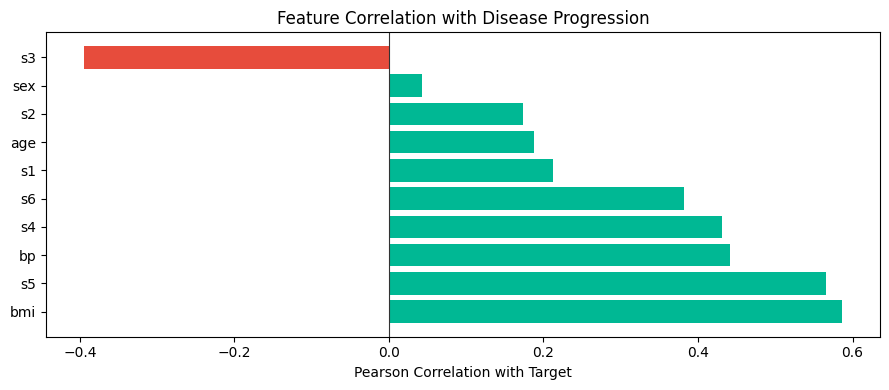

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789


In [5]:
# Correlation of each feature with the target
corr = df.corr()['target'].drop('target').sort_values(ascending=False)

plt.figure(figsize=(9, 4))
colors = ['#00b894' if v > 0 else '#e74c3c' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors, edgecolor='none')
plt.axvline(0, color='#333', linewidth=0.8)
plt.xlabel("Pearson Correlation with Target")
plt.title("Feature Correlation with Disease Progression")
plt.tight_layout()
plt.show()

print(corr.to_string())

<div style="background: #f0fafa; border-left: 4px solid #00b894; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #00695c;">💡 Observation:</strong> <code>bmi</code>, <code>s5</code> (log triglycerides), and <code>bp</code> are most positively correlated with progression. <code>s3</code> (HDL — the "good" cholesterol) is negatively correlated, which is medically sensible.
</div>

In [6]:
# Train / test split — 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size : {X_test.shape[0]} samples")

Train size: 331 samples
Test size : 111 samples


<a id='linear'></a>
<div style="border-bottom: 2px solid #00b894; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #00b894; color: #003d2e; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #0a3d3d; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Baseline — Linear Regression</h2>
</div>

Before applying Ridge, we fit a plain **Ordinary Least Squares (OLS)** model to establish a baseline. OLS minimises only the prediction error with no constraints — this often leads to large, unstable coefficients when features are correlated.

In [7]:
L = LinearRegression()
L.fit(X_train, y_train)

y_pred = L.predict(X_test)

print("=" * 40)
print("   LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"R² score : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print()
print("Coefficients:")
for name, coef in zip(data.feature_names, L.coef_):
    print(f"  {name:>5}  {coef:+.2f}")
print(f"\nIntercept: {L.intercept_:.4f}")

   LINEAR REGRESSION RESULTS
R² score : 0.4849
RMSE     : 53.3696

Coefficients:
    age  +47.75
    sex  -241.99
    bmi  +531.97
     bp  +381.56
     s1  -918.50
     s2  +508.26
     s3  +116.95
     s4  +269.49
     s5  +695.81
     s6  +26.32

Intercept: 151.6652


<div style="background: #fff8f0; border-left: 4px solid #ffb74d; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #e65100;">⚠️ Notice the wild swings:</strong> The OLS coefficients include extreme values like <code>-918</code> (s1) and <code>+695</code> (s5). These large opposing coefficients signal <strong>multicollinearity</strong> — s1 and s2 are highly correlated blood lipid measurements, so OLS inflates their coefficients in opposite directions to compensate. Ridge will stabilise this.
</div>

<a id='ridge'></a>
<div style="border-bottom: 2px solid #00b894; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #00b894; color: #003d2e; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #0a3d3d; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Ridge Regression (alpha = 1)</h2>
</div>

Ridge adds the L2 penalty term to the OLS cost. The `alpha` parameter in sklearn corresponds to **λ** in the formula. We start with `alpha=1` as a sensible default and compare results directly against the OLS baseline.

In [8]:
R = Ridge(alpha=1)
R.fit(X_train, y_train)

y_pred1 = R.predict(X_test)

print("=" * 40)
print("   RIDGE REGRESSION RESULTS (α=1)")
print("=" * 40)
print(f"R² score : {r2_score(y_test, y_pred1):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred1)):.4f}")
print()
print("Coefficients:")
for name, coef in zip(data.feature_names, R.coef_):
    print(f"  {name:>5}  {coef:+.2f}")
print(f"\nIntercept: {R.intercept_:.4f}")

   RIDGE REGRESSION RESULTS (α=1)
R² score : 0.4384
RMSE     : 55.7268

Coefficients:
    age  +50.55
    sex  -67.72
    bmi  +278.30
     bp  +197.62
     s1  -6.25
     s2  -26.23
     s3  -151.39
     s4  +120.32
     s5  +215.85
     s6  +101.76

Intercept: 152.5141


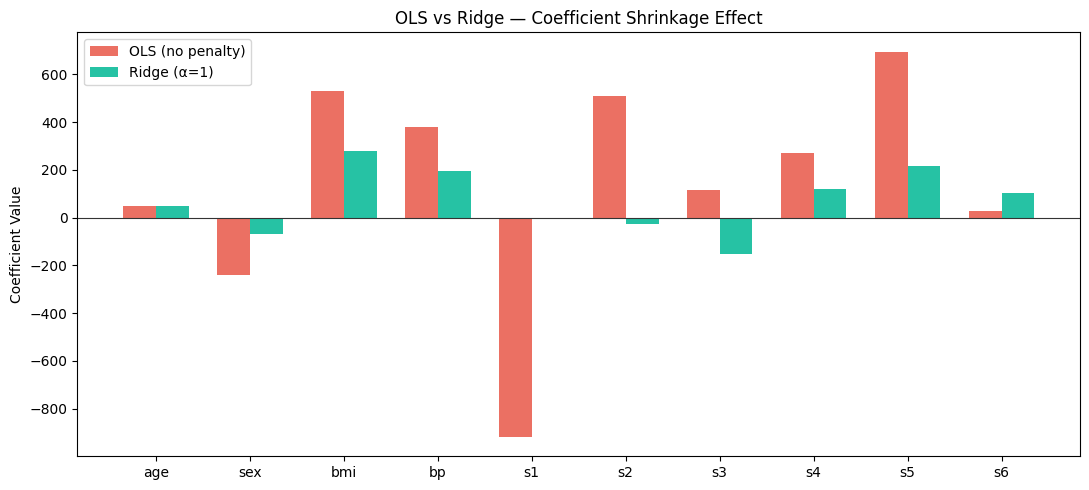

In [9]:
# Side-by-side coefficient comparison
x_pos = np.arange(len(data.feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_pos - width/2, L.coef_, width, label='OLS (no penalty)', color='#e74c3c', alpha=0.8)
ax.bar(x_pos + width/2, R.coef_, width, label='Ridge (α=1)',       color='#00b894', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(data.feature_names)
ax.axhline(0, color='#333', linewidth=0.8)
ax.set_ylabel("Coefficient Value")
ax.set_title("OLS vs Ridge — Coefficient Shrinkage Effect")
ax.legend()
plt.tight_layout()
plt.show()

<div style="background: #e8f5f0; border-left: 4px solid #00b894; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #00695c;">✅ Shrinkage in action:</strong> The extreme OLS values for <code>s1</code> (−918 → −6) and <code>s2</code> (+508 → −26) collapse dramatically. Ridge has absorbed the multicollinearity by distributing the weight more evenly. The model is now far more interpretable and stable.
</div>

<div style="background: #fafafa; border: 1px solid #ddd; border-radius: 10px; padding: 16px 24px; margin: 16px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px;">
    <div>
      <div style="color: #888; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">OLS R²</div>
      <div style="font-size: 26px; font-weight: 700; color: #e74c3c;">0.485</div>
    </div>
    <div>
      <div style="color: #888; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">Ridge R² (α=1)</div>
      <div style="font-size: 26px; font-weight: 700; color: #00b894;">0.438</div>
    </div>
    <div>
      <div style="color: #888; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">OLS RMSE</div>
      <div style="font-size: 26px; font-weight: 700; color: #e74c3c;">53.37</div>
    </div>
    <div>
      <div style="color: #888; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">Ridge RMSE (α=1)</div>
      <div style="font-size: 26px; font-weight: 700; color: #00b894;">55.73</div>
    </div>
  </div>
  <div style="margin-top: 12px; font-size: 13px; color: #666; border-top: 1px solid #eee; padding-top: 10px;">
    💡 OLS scores slightly higher here because the data is not severely overfit — this dataset has only 10 features. Ridge's true advantage shows when features are many, noisy, or correlated. Try a higher polynomial degree to see the difference amplify.
  </div>
</div>

<a id='alpha'></a>
<div style="border-bottom: 2px solid #00b894; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #00b894; color: #003d2e; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #0a3d3d; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Effect of Alpha — Visualizing the Shrinkage</h2>
</div>

To really see what `alpha` (λ) does, we generate a synthetic **non-linear dataset** and fit a degree-16 polynomial pipeline with Ridge at three different alpha values. This deliberately exaggerates the problem so the regularization effect is unmistakable.

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin: 16px 0;">
  <div style="background: #fff3f3; border: 1px solid #ffcdd2; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 20px; margin-bottom: 6px;">🔴</div>
    <div style="color: #c62828; font-weight: 700; font-size: 13px;">alpha = 0</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">No penalty — pure OLS on degree-16. Extreme overfitting, wild oscillations.</div>
  </div>
  <div style="background: #f0fff4; border: 1px solid #c8e6c9; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 20px; margin-bottom: 6px;">🟢</div>
    <div style="color: #2e7d32; font-weight: 700; font-size: 13px;">alpha = 20</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">Moderate penalty — smoother curve, good fit to the underlying pattern.</div>
  </div>
  <div style="background: #e8f4fd; border: 1px solid #bbdefb; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 20px; margin-bottom: 6px;">🔵</div>
    <div style="color: #1565c0; font-weight: 700; font-size: 13px;">alpha = 200</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">Heavy penalty — coefficients severely shrunk. Starts underfitting slightly.</div>
  </div>
</div>

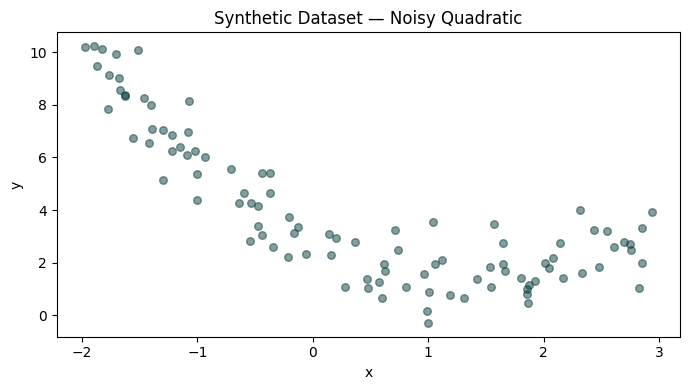

In [10]:
np.random.seed(42)

m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x1, x2, color='#0a3d3d', alpha=0.5, s=30)
plt.title("Synthetic Dataset — Noisy Quadratic")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

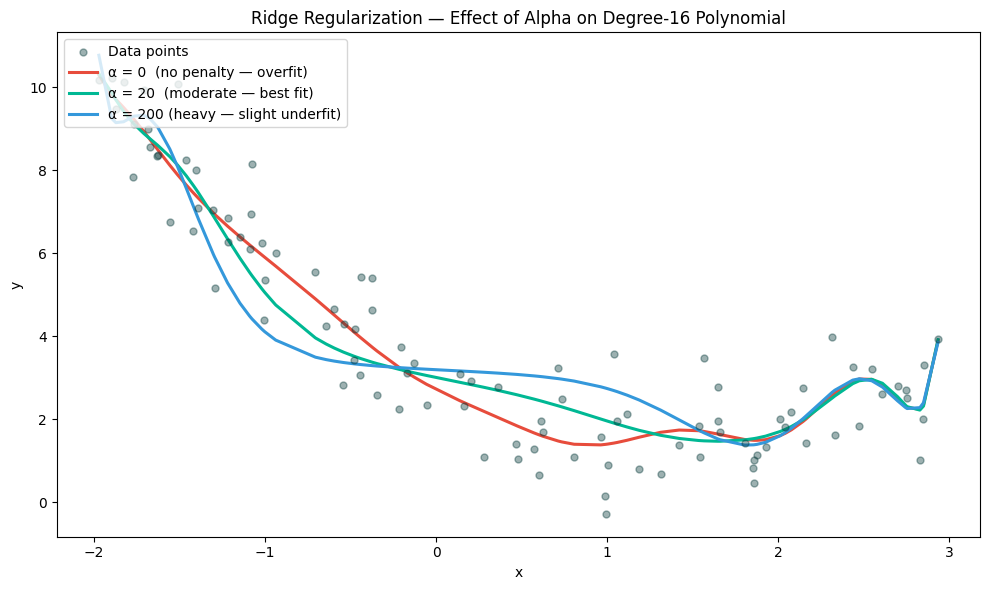

In [11]:
def get_preds_ridge(x1, x2, alpha):
    """Fit a degree-16 polynomial Ridge pipeline and return predictions sorted by x."""
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge',      Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0,   20,      200]
colors = ['#e74c3c', '#00b894', '#3498db']
labels = ['α = 0  (no penalty — overfit)',
          'α = 20  (moderate — best fit)',
          'α = 200 (heavy — slight underfit)']

plt.figure(figsize=(10, 6))
plt.scatter(x1, x2, color='#0a3d3d', alpha=0.4, s=25, zorder=5, label='Data points')

sort_idx = np.argsort(x1[:, 0])
x_sorted = x1[sort_idx, 0]

for alpha, c, lbl in zip(alphas, colors, labels):
    preds = get_preds_ridge(x1, x2, alpha)
    plt.plot(x_sorted, preds[sort_idx], color=c, linewidth=2.2, label=lbl)

plt.legend(loc='upper left', fontsize=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ridge Regularization — Effect of Alpha on Degree-16 Polynomial")
plt.tight_layout()
plt.show()

<div style="background: #f0fafa; border-left: 4px solid #00b894; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #00695c;">✅ Key insight:</strong> The red curve (α=0) is a textbook overfit — it passes through almost every noise spike. The green curve (α=20) smoothly traces the true quadratic pattern underneath. The blue (α=200) is smoother still but starts losing the curve's shape. In practice, use <strong>RidgeCV</strong> to find the optimal alpha via cross-validation automatically.
</div>

<a id='summary'></a>
<div style="background: linear-gradient(135deg, #0d2b2b 0%, #0a3d3d 100%); border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 20px 0;">📌 Summary &amp; Key Takeaways</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #00b894; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🧊 What Ridge Does</div>
      <div style="color: #a0c4c4; font-size: 13px; line-height: 1.6;">Adds <strong style='color:#fff;'>λ·Σθᵢ²</strong> to the loss. Forces coefficients toward zero — but never exactly to zero. All features stay in the model.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #00b894; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚖️ Choosing Alpha</div>
      <div style="color: #a0c4c4; font-size: 13px; line-height: 1.6;">Too low → overfitting (like OLS). Too high → underfitting. Use <strong style='color:#fff;'>RidgeCV</strong> to search automatically with cross-validation.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #00b894; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔗 When to Use Ridge</div>
      <div style="color: #a0c4c4; font-size: 13px; line-height: 1.6;">Best when features are <strong style='color:#fff;'>correlated (multicollinearity)</strong> or when you have many features all expected to contribute a little.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #00b894; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔄 Ridge vs Lasso</div>
      <div style="color: #a0c4c4; font-size: 13px; line-height: 1.6;">Ridge (L2) shrinks. Lasso (L1) eliminates. Need <strong style='color:#fff;'>feature selection?</strong> → Lasso. Need stable predictions with correlated inputs? → Ridge.</div>
    </div>
  </div>
  <div style="margin-top: 20px; padding-top: 16px; border-top: 1px solid rgba(255,255,255,0.1); color: #7aafaf; font-size: 12px;">
    Next up → <strong style='color:#00b894;'>ML 36: Lasso Regularization</strong> — L1 penalty, sparse models &amp; automatic feature selection.
  </div>
</div>